# Modélisation — Prédiction du Churn Client

Ce notebook est dédié à l'entraînement et à la comparaison des modèles de Machine Learning et Deep Learning.
L'évaluation approfondie (métriques détaillées, matrices de confusion, Feature Importance, SHAP) est traitée dans `04_Evaluation.ipynb`.

**Plan :**
1. Chargement des données prétraitées
2. Fonction d'évaluation rapide
3. Modèle 1 — Régression Logistique (Baseline)
4. Modèle 2 — Random Forest
5. Modèle 3 — XGBoost
6. Modèle 4 — MLP (Deep Learning)
7. Comparaison synthétique
8. Validation croisée du meilleur modèle
9. Sélection et justification du modèle final
10. Sauvegarde des modèles

## 1. Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

print('✅ Librairies importées avec succès !')

✅ Librairies importées avec succès !


## 2. Chargement des données prétraitées

In [2]:
X_train       = np.load('../models/X_train_prepared.npy')
X_test        = np.load('../models/X_test_prepared.npy')
X_train_ros   = np.load('../models/X_train_ros.npy')
X_train_smote = np.load('../models/X_train_smote.npy')
X_train_rus   = np.load('../models/X_train_rus.npy')
y_train       = np.load('../models/y_train.npy')
y_test        = np.load('../models/y_test.npy')
y_train_ros   = np.load('../models/y_train_ros.npy')
y_train_smote = np.load('../models/y_train_smote.npy')
y_train_rus   = np.load('../models/y_train_rus.npy')

print('✅ Données chargées !')
print(f'   X_train (original) : {X_train.shape}')
print(f'   X_test             : {X_test.shape}')
print(f'   X_train_ros        : {X_train_ros.shape}')
print(f'   X_train_smote      : {X_train_smote.shape}')
print(f'   X_train_rus        : {X_train_rus.shape}')

✅ Données chargées !
   X_train (original) : (8000, 51)
   X_test             : (2000, 51)
   X_train_ros        : (14366, 51)
   X_train_smote      : (14366, 51)
   X_train_rus        : (1634, 51)


## 3. Fonction d'évaluation rapide

Cette fonction retourne les métriques clés pour la comparaison entre modèles.
L'analyse détaillée (matrices de confusion, courbes ROC, SHAP) est dans `04_Evaluation.ipynb`.

In [3]:
def evaluate_model(model, X_test, y_test, model_name='Modèle', verbose=True):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        'Modèle'   : model_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4)
    }
    if verbose:
        print(f"\n{'='*50}")
        print(f'  📊 {model_name}')
        print(f"{'='*50}")
        for k, v in metrics.items():
            if k != 'Modèle':
                print(f'   {k:<12} : {v}')
    return metrics

print('✅ Fonction evaluate_model définie !')

✅ Fonction evaluate_model définie !


## 4. Modèle 1 — Régression Logistique (Baseline)

La régression logistique sert de point de référence. Elle est rapide et interprétable, mais limitée aux relations linéaires entre variables.

`class_weight='balanced'` compense le déséquilibre 90/10 sans rééchantillonnage.

In [4]:
strategies = [
    ('RL + Original', X_train,       y_train),
    ('RL + ROS',      X_train_ros,   y_train_ros),
    ('RL + SMOTE',    X_train_smote, y_train_smote),
    ('RL + RUS',      X_train_rus,   y_train_rus),
]

lr_results = []

for name, X_tr, y_tr in strategies:

    lr_tmp = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

    lr_tmp.fit(X_tr, y_tr)

    m = evaluate_model(
        lr_tmp,
        X_test,
        y_test,
        model_name=name,
        verbose=False
    )

    lr_results.append(m)

    print(f'  ✅ {name:<20} | Recall: {m["Recall"]:.4f} | F1: {m["F1-Score"]:.4f} | ROC-AUC: {m["ROC-AUC"]:.4f}')

lr_df = pd.DataFrame(lr_results).set_index("Modèle")

print("\n📊 Tableau comparatif — Régression Logistique par stratégie :")
display(lr_df)

  ✅ RL + Original        | Recall: 0.6520 | F1: 0.2863 | ROC-AUC: 0.7212
  ✅ RL + ROS             | Recall: 0.6422 | F1: 0.2796 | ROC-AUC: 0.7180
  ✅ RL + SMOTE           | Recall: 0.6275 | F1: 0.2819 | ROC-AUC: 0.7112
  ✅ RL + RUS             | Recall: 0.6373 | F1: 0.2737 | ROC-AUC: 0.7094

📊 Tableau comparatif — Régression Logistique par stratégie :


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
RL + Original,0.6685,0.1834,0.6520,0.2863,0.7212
RL + ROS,0.6625,0.1787,0.6422,0.2796,0.7180
RL + SMOTE,0.6740,0.1818,0.6275,0.2819,0.7112
RL + RUS,0.6550,0.1743,0.6373,0.2737,0.7094


In [5]:
# Entraînement de la meilleure RL (Original)
best_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

best_lr.fit(X_train, y_train)

print("✅ Régression Logistique finale entraînée !")

metrics_lr = evaluate_model(
    best_lr,
    X_test,
    y_test,
    model_name="Régression Logistique + Original"
)

✅ Régression Logistique finale entraînée !

  📊 Régression Logistique + Original
   Accuracy     : 0.6685
   Precision    : 0.1834
   Recall       : 0.652
   F1-Score     : 0.2863
   ROC-AUC      : 0.7212


### Analyse

Nous avons comparé quatre stratégies de rééquilibrage (Original, ROS, SMOTE et RUS) avec la Régression Logistique. Les performances obtenues sont très proches, et les données originales associées à class_weight='balanced' offrent les meilleurs résultats en termes de Recall, de F1-score et de ROC-AUC parmi les stratégies testées. Cela montre que, pour ce modèle, le mécanisme interne de pondération des classes est suffisant pour gérer le déséquilibre du jeu de données, sans qu'un rééchantillonnage supplémentaire n'apporte d'amélioration significative.

### Remarque

La régression logistique établit notre référence. En tant que modèle linéaire, elle ne capture pas les interactions complexes entre variables comportementales. Le **Recall** (priorité métier) sera le critère principal pour juger si les modèles suivants apportent une réelle amélioration.

## 5. Modèle 2 — Random Forest

Le Random Forest construit de nombreux arbres de décision en parallèle (bagging) et agrège leurs prédictions. Il capture des relations non linéaires et est robuste à l'overfitting.

On compare les 4 stratégies de rééquilibrage pour choisir la meilleure combinaison.

In [6]:
strategies = [
    ('RF + Original', X_train,       y_train),
    ('RF + ROS',      X_train_ros,   y_train_ros),
    ('RF + SMOTE',    X_train_smote, y_train_smote),
    ('RF + RUS',      X_train_rus,   y_train_rus),
]

rf_results = []
for name, X_tr, y_tr in strategies:
    rf_tmp = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_tmp.fit(X_tr, y_tr)
    m = evaluate_model(rf_tmp, X_test, y_test, model_name=name, verbose=False)
    rf_results.append(m)
    print(f'  ✅ {name:<20} | Recall: {m["Recall"]:.4f} | F1: {m["F1-Score"]:.4f} | ROC-AUC: {m["ROC-AUC"]:.4f}')

rf_df = pd.DataFrame(rf_results).set_index('Modèle')
print('\n📊 Tableau comparatif — Random Forest par stratégie :')
display(rf_df)

  ✅ RF + Original        | Recall: 0.1127 | F1: 0.1736 | ROC-AUC: 0.8033
  ✅ RF + ROS             | Recall: 0.0147 | F1: 0.0282 | ROC-AUC: 0.7924
  ✅ RF + SMOTE           | Recall: 0.0196 | F1: 0.0372 | ROC-AUC: 0.7877
  ✅ RF + RUS             | Recall: 0.8333 | F1: 0.3799 | ROC-AUC: 0.7981

📊 Tableau comparatif — Random Forest par stratégie :


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
RF + Original,0.8905,0.3770,0.1127,0.1736,0.8033
RF + ROS,0.8965,0.3333,0.0147,0.0282,0.7924
RF + SMOTE,0.8965,0.3636,0.0196,0.0372,0.7877
RF + RUS,0.7225,0.2460,0.8333,0.3799,0.7981


En choisissant RUS, nous acceptons une diminution de l'Accuracy afin d'améliorer fortement le Recall. Ce compromis est cohérent avec notre objectif métier, qui est de détecter un maximum de churners, même si cela génère davantage de fausses alertes.

In [7]:
# Entraînement du meilleur RF (RUS retenu)
best_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_rus, y_train_rus)
print('✅ Random Forest final entraîné (RUS) !')
metrics_rf = evaluate_model(best_rf, X_test, y_test, model_name='Random Forest + RUS')

✅ Random Forest final entraîné (RUS) !

  📊 Random Forest + RUS
   Accuracy     : 0.7225
   Precision    : 0.246
   Recall       : 0.8333
   F1-Score     : 0.3799
   ROC-AUC      : 0.7981


### Analyse

Nous avons comparé quatre stratégies d'entraînement du Random Forest : les données originales, ROS, SMOTE et RUS. Les résultats montrent que Random Under Sampling (RUS) obtient le meilleur Recall (0,8333) ainsi que le meilleur F1-score (0,3799). Bien que son Accuracy soit plus faible, cette baisse est acceptable dans notre contexte métier, où l'objectif principal est d'identifier un maximum de clients susceptibles de résilier. Nous avons donc retenu RUS comme stratégie de rééquilibrage pour entraîner la version finale de Random Forest.

## 6. Modèle 3 — XGBoost

XGBoost (eXtreme Gradient Boosting) construit les arbres séquentiellement : chaque arbre corrige les erreurs du précédent via la descente de gradient. C'est l'un des algorithmes les plus performants sur les données tabulaires structurées.

In [8]:
# Comparaison des différentes stratégies de rééquilibrage

strategies = [
    ('XGB + Original', X_train,       y_train),
    ('XGB + ROS',      X_train_ros,   y_train_ros),
    ('XGB + SMOTE',    X_train_smote, y_train_smote),
    ('XGB + RUS',      X_train_rus,   y_train_rus),
]

xgb_results = []

for name, X_tr, y_tr in strategies:

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    scale = neg / pos
    print(f"scale_pos_weight = {scale:.2f}")

    xgb_tmp = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    xgb_tmp.fit(X_tr, y_tr)

    m = evaluate_model(
        xgb_tmp,
        X_test,
        y_test,
        model_name=name,
        verbose=False
    )

    xgb_results.append(m)

    print(
        f'  ✅ {name:<20} | '
        f'Recall: {m["Recall"]:.4f} | '
        f'F1: {m["F1-Score"]:.4f} | '
        f'ROC-AUC: {m["ROC-AUC"]:.4f}'
    )

xgb_df = pd.DataFrame(xgb_results).set_index("Modèle")

print("\n📊 Tableau comparatif — XGBoost par stratégie :")
display(xgb_df)

scale_pos_weight = 8.79
  ✅ XGB + Original       | Recall: 0.2941 | F1: 0.2740 | ROC-AUC: 0.7718
scale_pos_weight = 1.00
  ✅ XGB + ROS            | Recall: 0.3725 | F1: 0.3173 | ROC-AUC: 0.7753
scale_pos_weight = 1.00
  ✅ XGB + SMOTE          | Recall: 0.0637 | F1: 0.1074 | ROC-AUC: 0.7882
scale_pos_weight = 1.00
  ✅ XGB + RUS            | Recall: 0.8137 | F1: 0.3685 | ROC-AUC: 0.7927

📊 Tableau comparatif — XGBoost par stratégie :


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
XGB + Original,0.8410,0.2564,0.2941,0.2740,0.7718
XGB + ROS,0.8365,0.2764,0.3725,0.3173,0.7753
XGB + SMOTE,0.8920,0.3421,0.0637,0.1074,0.7882
XGB + RUS,0.7155,0.2382,0.8137,0.3685,0.7927


In [9]:
# Entraînement du meilleur XGBoost (RUS retenu)

neg = (y_train_rus == 0).sum()
pos = (y_train_rus == 1).sum()
scale = neg / pos

best_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train_rus, y_train_rus)

print("✅ XGBoost final entraîné (RUS) !")

metrics_xgb = evaluate_model(
    best_xgb,
    X_test,
    y_test,
    model_name="XGBoost + RUS"
)

✅ XGBoost final entraîné (RUS) !

  📊 XGBoost + RUS
   Accuracy     : 0.7155
   Precision    : 0.2382
   Recall       : 0.8137
   F1-Score     : 0.3685
   ROC-AUC      : 0.7927


### Analyse

Nous avons comparé quatre stratégies de gestion du déséquilibre (Original, ROS, SMOTE et RUS) pour entraîner XGBoost.

Les résultats montrent que **Random Under Sampling (RUS)** offre les meilleures performances en termes de Recall, de F1-score et de ROC-AUC.

Nous retenons donc cette stratégie pour entraîner la version finale de XGBoost.

### Choix des hyperparamètres

Le modèle XGBoost utilise un `learning_rate` faible (0,05) associé à `300` arbres afin de favoriser un apprentissage progressif et de limiter le risque de surapprentissage.

Le paramètre `max_depth=6` limite la complexité des arbres.

Enfin, `subsample=0.8` et `colsample_bytree=0.8` introduisent une régularisation en utilisant seulement 80 % des observations et 80 % des variables pour chaque arbre, ce qui améliore la capacité de généralisation du modèle.

## 7. Modèle 4 — MLP (Deep Learning)

Le MLP (Multi-Layer Perceptron) est un réseau de neurones à couches cachées. Il peut capturer des interactions très complexes et non linéaires entre variables comportementales.

**Justification du Deep Learning** : les comportements clients (usage × satisfaction × paiements) impliquent des interactions multi-dimensionnelles potentiellement difficiles à capturer pour un arbre de décision unique. Le MLP est inclus pour comparer empiriquement son apport par rapport au gradient boosting.

In [10]:
strategies = [
    ('MLP + Original', X_train,       y_train),
    ('MLP + ROS',      X_train_ros,   y_train_ros),
    ('MLP + SMOTE',    X_train_smote, y_train_smote),
    ('MLP + RUS',      X_train_rus,   y_train_rus),
]

mlp_results = []

for name, X_tr, y_tr in strategies:

    mlp_tmp = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=256,
        learning_rate='adaptive',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    )

    mlp_tmp.fit(X_tr, y_tr)

    m = evaluate_model(
        mlp_tmp,
        X_test,
        y_test,
        model_name=name,
        verbose=False
    )

    mlp_results.append(m)

    print(
        f'  ✅ {name:<20} | '
        f'Recall: {m["Recall"]:.4f} | '
        f'F1: {m["F1-Score"]:.4f} | '
        f'ROC-AUC: {m["ROC-AUC"]:.4f}'
    )

mlp_df = pd.DataFrame(mlp_results).set_index("Modèle")

print("\n📊 Tableau comparatif — MLP par stratégie :")
display(mlp_df)

  ✅ MLP + Original       | Recall: 0.0000 | F1: 0.0000 | ROC-AUC: 0.6194
  ✅ MLP + ROS            | Recall: 0.2059 | F1: 0.2014 | ROC-AUC: 0.6868
  ✅ MLP + SMOTE          | Recall: 0.2108 | F1: 0.2222 | ROC-AUC: 0.6669
  ✅ MLP + RUS            | Recall: 0.6225 | F1: 0.2581 | ROC-AUC: 0.6872

📊 Tableau comparatif — MLP par stratégie :


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
MLP + Original,0.8980,0.0000,0.0000,0.0000,0.6194
MLP + ROS,0.8335,0.1972,0.2059,0.2014,0.6868
MLP + SMOTE,0.8495,0.2350,0.2108,0.2222,0.6669
MLP + RUS,0.6350,0.1628,0.6225,0.2581,0.6872


In [11]:
best_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate='adaptive',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

best_mlp.fit(X_train_rus, y_train_rus)

print(f'✅ MLP final entraîné ! ({best_mlp.n_iter_} itérations)')

metrics_mlp = evaluate_model(
    best_mlp,
    X_test,
    y_test,
    model_name='MLP + RUS'
)

✅ MLP final entraîné ! (25 itérations)

  📊 MLP + RUS
   Accuracy     : 0.635
   Precision    : 0.1628
   Recall       : 0.6225
   F1-Score     : 0.2581
   ROC-AUC      : 0.6872


## Analyse

Nous avons comparé quatre stratégies de gestion du déséquilibre (Original, ROS, SMOTE et RUS) pour entraîner le réseau de neurones MLP. Les résultats montrent que RUS offre le meilleur compromis entre Recall, F1-score et ROC-AUC. Cette stratégie permet au modèle de détecter davantage de churners tout en conservant de bonnes performances globales. Nous retenons donc RUS pour entraîner la version finale du MLP.

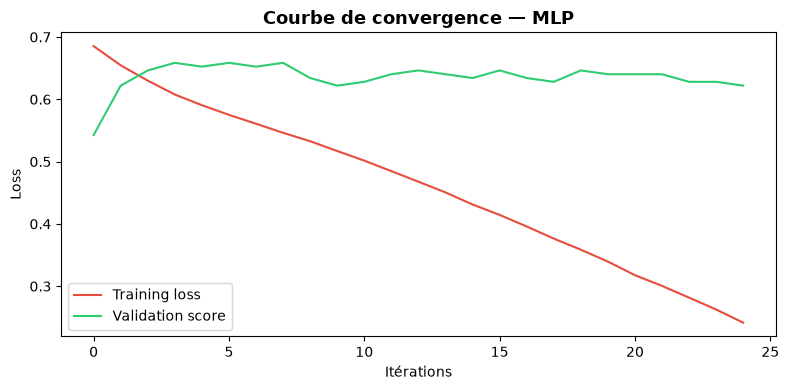

📊 La convergence et l'absence d'overfitting sont confirmées par l'early stopping.


In [12]:
# Courbe de convergence
plt.figure(figsize=(8, 4))

plt.plot(best_mlp.loss_curve_, color='#e74c3c', label='Training loss')

if hasattr(best_mlp, 'validation_scores_'):
    plt.plot(best_mlp.validation_scores_,
             color='#2ecc71',
             label='Validation score')

plt.title('Courbe de convergence — MLP', fontsize=13, fontweight='bold')
plt.xlabel('Itérations')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

print("📊 La convergence et l'absence d'overfitting sont confirmées par l'early stopping.")

La courbe montre que le modèle converge correctement. L'option early_stopping permet d'interrompre automatiquement l'entraînement lorsque les performances sur les données de validation ne s'améliorent plus, ce qui contribue à limiter le risque de surapprentissage.

## Analyse critique — Deep Learning vs Machine Learning classique

| Dimension | MLP (Deep Learning) | Modèles de Machine Learning |
|---|---|---|
| Relations non linéaires | ✅ Très bonne capacité | ✅ Bonne à très bonne selon le modèle |
| Interprétabilité | ❌ Faible (boîte noire) | ✅ Généralement meilleure (importance des variables, SHAP) |
| Temps d'entraînement | ⚠️ Plus élevé | ✅ Généralement plus rapide |
| Gestion du surapprentissage | Régularisation L2 + Early Stopping | Régularisation propre à chaque algorithme |
| Performances sur notre jeu de données | Améliorées avec RUS mais inférieures aux meilleurs modèles | ✅ Meilleur compromis obtenu avec Random Forest + RUS |

### Analyse

Le **MLP (Multi-Layer Perceptron)** est un réseau de neurones capable d'apprendre des relations complexes entre les variables. Afin de limiter le risque de surapprentissage, nous avons utilisé une **régularisation L2 (`alpha=0.001`)** ainsi que l'**Early Stopping**, qui interrompt automatiquement l'entraînement lorsque les performances sur les données de validation cessent de progresser.

La courbe d'apprentissage montre une diminution régulière de la perte sur les données d'entraînement, tandis que le score de validation se stabilise rapidement. Cela indique que le modèle continue d'apprendre, mais que ses performances sur de nouvelles données n'évoluent plus significativement. L'**Early Stopping** permet ainsi de limiter le surapprentissage et de favoriser une meilleure généralisation.

Les expérimentations montrent cependant que, sur notre jeu de données, les modèles de **Machine Learning classique** obtiennent de meilleures performances que le MLP. En particulier, **Random Forest entraîné avec la stratégie Random Under Sampling (RUS)** offre le meilleur compromis entre **Recall**, **F1-score** et **ROC-AUC**.

Ces résultats montrent qu'un modèle de **Deep Learning** n'est pas systématiquement le plus performant. Le choix du modèle dépend avant tout de la nature des données, du volume d'observations disponible et des performances obtenues expérimentalement. Dans notre cas, un modèle d'ensemble basé sur des arbres s'est révélé plus adapté à la prédiction du churn.

## 8. Comparaison synthétique des 4 modèles

In [13]:
# Comparaison des meilleurs modèles

all_metrics = [
    metrics_lr,
    metrics_rf,
    metrics_xgb,
    metrics_mlp
]

results_df = pd.DataFrame(all_metrics).set_index("Modèle")

print("📊 Comparaison des meilleurs modèles")

display(
    results_df.style
        .highlight_max(axis=0, color="#d4f0d4")
        .highlight_min(axis=0, color="#f8d7da")
        .format("{:.4f}")
)

print("\n🟢 Vert : meilleure performance pour chaque métrique")
print("🔴 Rouge : performance la plus faible")

📊 Comparaison des meilleurs modèles


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Régression Logistique + Original,0.6685,0.1834,0.6520,0.2863,0.7212
Random Forest + RUS,0.7225,0.2460,0.8333,0.3799,0.7981
XGBoost + RUS,0.7155,0.2382,0.8137,0.3685,0.7927
MLP + RUS,0.6350,0.1628,0.6225,0.2581,0.6872



🟢 Vert : meilleure performance pour chaque métrique
🔴 Rouge : performance la plus faible


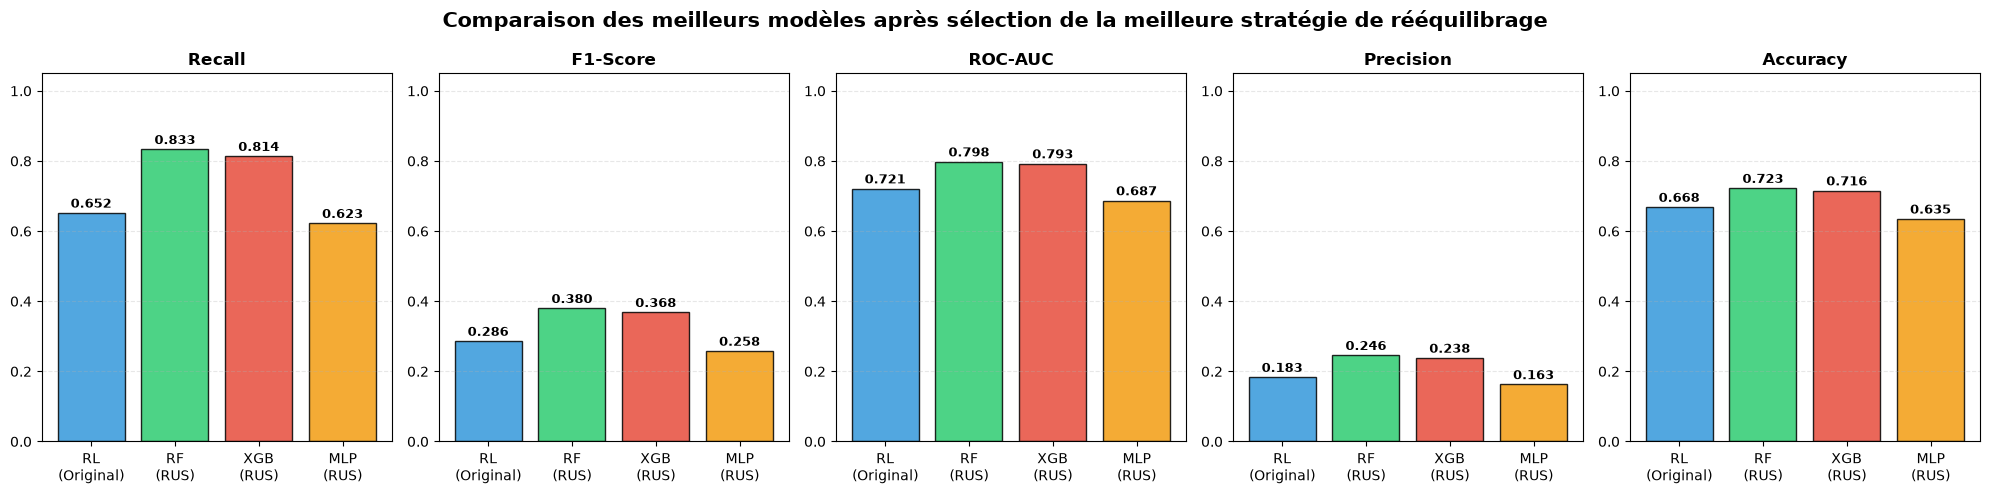

In [14]:
metrics_to_plot = ['Recall', 'F1-Score', 'ROC-AUC', 'Precision', 'Accuracy']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

model_labels = ['RL\n(Original)', 'RF\n(RUS)', 'XGB\n(RUS)', 'MLP\n(RUS)']

for i, metric in enumerate(metrics_to_plot):

    values = results_df[metric].values

    bars = axes[i].bar(
        range(len(model_labels)),
        values,
        color=colors,
        edgecolor='black',
        alpha=0.85
    )

    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xticks(range(len(model_labels)))
    axes[i].set_xticklabels(model_labels, fontsize=10)
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

    for bar, val in zip(bars, values):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            val + 0.015,
            f'{val:.3f}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

plt.suptitle(
    'Comparaison des meilleurs modèles après sélection de la meilleure stratégie de rééquilibrage',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 9. Validation croisée du meilleur modèle

Après avoir comparé les différents modèles et les stratégies de rééquilibrage, **Random Forest associé à Random Under Sampling (RUS)** a été retenu comme meilleur modèle.

Une **validation croisée à 5 plis (5-Fold Cross Validation)** est ensuite réalisée afin de vérifier la **stabilité** et la **capacité de généralisation** du modèle.

Cette étape permet d'évaluer les performances du modèle sur plusieurs découpages différents du jeu de données et de s'assurer que les bons résultats obtenus ne sont pas dus à un unique partage des données d'entraînement et de test.

In [15]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import joblib

# Chargement des données complètes
df_full = pd.read_csv('../data/customer_churn_business_dataset.csv')

# Chargement du pipeline de prétraitement
preprocessor = joblib.load('../models/preprocessor.pkl')

# Préparation des données
df_full = df_full.drop(columns=['customer_id', 'city'])
X_full = df_full.drop(columns=['churn'])
y_full = df_full['churn']

# Pipeline complet : Prétraitement → RUS → Random Forest
pipe_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('rus', RandomUnderSampler(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Validation croisée stratifiée
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Évaluation
cv_f1 = cross_val_score(
    pipe_cv,
    X_full,
    y_full,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

cv_auc = cross_val_score(
    pipe_cv,
    X_full,
    y_full,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

cv_rec = cross_val_score(
    pipe_cv,
    X_full,
    y_full,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

print("📊 Validation croisée — Random Forest + RUS (5 folds stratifiés)")
print(f"   Recall   : {cv_rec.mean():.4f} ± {cv_rec.std():.4f}")
print(f"   F1-Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"   ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

print("\n✅ Un faible écart-type entre les différents plis confirme que le modèle est stable et généralise correctement sur des données non vues.")

📊 Validation croisée — Random Forest + RUS (5 folds stratifiés)
   Recall   : 0.8100 ± 0.0219
   F1-Score : 0.3723 ± 0.0033
   ROC-AUC  : 0.7965 ± 0.0155

✅ Un faible écart-type entre les différents plis confirme que le modèle est stable et généralise correctement sur des données non vues.


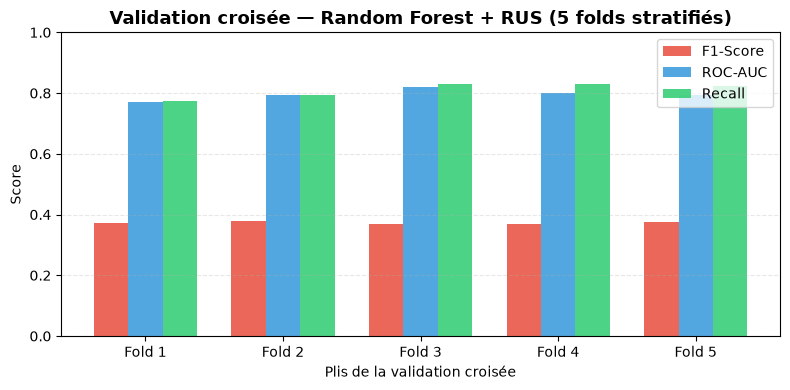

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(5)
w = 0.25

ax.bar(x - w, cv_f1,  width=w, label='F1-Score', color='#e74c3c', alpha=0.85)
ax.bar(x,     cv_auc, width=w, label='ROC-AUC',  color='#3498db', alpha=0.85)
ax.bar(x + w, cv_rec, width=w, label='Recall',   color='#2ecc71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])

ax.set_ylim(0, 1)

ax.set_xlabel('Plis de la validation croisée')
ax.set_ylabel('Score')

ax.set_title(
    'Validation croisée — Random Forest + RUS (5 folds stratifiés)',
    fontsize=13,
    fontweight='bold'
)

ax.grid(axis='y', linestyle='--', alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

## 10. Sélection et justification du modèle final

In [17]:
synthese = pd.DataFrame([
    {'Modèle': 'Régression Logistique (Original)',
     'Recall': metrics_lr['Recall'],
     'F1': metrics_lr['F1-Score'],
     'ROC-AUC': metrics_lr['ROC-AUC'],
     'Interprétabilité': '⭐⭐⭐⭐⭐',
     'Vitesse': '⭐⭐⭐⭐⭐',
     'Complexité': 'Faible'},

    {'Modèle': '🏆 Random Forest + RUS',
     'Recall': metrics_rf['Recall'],
     'F1': metrics_rf['F1-Score'],
     'ROC-AUC': metrics_rf['ROC-AUC'],
     'Interprétabilité': '⭐⭐⭐⭐',
     'Vitesse': '⭐⭐⭐⭐',
     'Complexité': 'Moyenne'},

    {'Modèle': 'XGBoost + RUS',
     'Recall': metrics_xgb['Recall'],
     'F1': metrics_xgb['F1-Score'],
     'ROC-AUC': metrics_xgb['ROC-AUC'],
     'Interprétabilité': '⭐⭐⭐⭐',
     'Vitesse': '⭐⭐⭐',
     'Complexité': 'Moyenne à élevée'},

    {'Modèle': 'MLP + RUS',
     'Recall': metrics_mlp['Recall'],
     'F1': metrics_mlp['F1-Score'],
     'ROC-AUC': metrics_mlp['ROC-AUC'],
     'Interprétabilité': '⭐⭐',
     'Vitesse': '⭐⭐',
     'Complexité': 'Élevée'}
])

display(
    synthese.style
        .set_properties(subset=['Modèle'], **{'text-align': 'left'})
)

,Modèle,Recall,F1,ROC-AUC,Interprétabilité,Vitesse,Complexité
0,Régression Logistique (Original),0.652000,0.286300,0.721200,⭐⭐⭐⭐⭐,⭐⭐⭐⭐⭐,Faible
1,🏆 Random Forest + RUS,0.833300,0.379900,0.798100,⭐⭐⭐⭐,⭐⭐⭐⭐,Moyenne
2,XGBoost + RUS,0.813700,0.368500,0.792700,⭐⭐⭐⭐,⭐⭐⭐,Moyenne à élevée
3,MLP + RUS,0.622500,0.258100,0.687200,⭐⭐,⭐⭐,Élevée


## Justification — Random Forest + RUS sélectionné comme modèle final

Après comparaison des quatre modèles et des différentes stratégies de rééquilibrage, **Random Forest associé à Random Under Sampling (RUS)** a été retenu comme modèle final.

Ce choix est justifié par plusieurs éléments :

- **Performance** : il obtient le meilleur **Recall (0,8333)**, le meilleur **F1-score (0,3799)** et le meilleur **ROC-AUC (0,7981)** parmi les modèles évalués sur notre jeu de données.
- **Stabilité** : la validation croisée à 5 plis confirme la robustesse du modèle, avec de faibles écarts-types sur les principales métriques.
- **Adaptation au problème métier** : grâce au **Recall** élevé, le modèle détecte un maximum de clients susceptibles de résilier, ce qui est l'objectif principal d'un projet de prédiction du churn.
- **Interprétabilité** : bien qu'il soit plus complexe qu'une régression logistique, Random Forest permet d'analyser l'importance des variables et peut être interprété avec des outils comme **SHAP**, facilitant ainsi la compréhension des prédictions.
- **Déployabilité** : le modèle peut être sauvegardé avec **Joblib** et intégré facilement dans une API ou une application métier.

### Pourquoi pas XGBoost ?

XGBoost obtient également de très bonnes performances, mais celles-ci restent légèrement inférieures à celles de **Random Forest + RUS** sur notre jeu de données, notamment en **Recall**, **F1-score** et **ROC-AUC**.

### Pourquoi pas le MLP ?

Le MLP est capable d'apprendre des relations complexes entre les variables, mais il obtient des performances inférieures sur ce jeu de données. De plus, il est moins interprétable et nécessite davantage de ressources pour son entraînement.

Ces expérimentations montrent que le choix d'un modèle dépend avant tout des **résultats obtenus sur les données étudiées** et non uniquement de la complexité de l'algorithme.

## 11. Sauvegarde des modèles

In [18]:
joblib.dump(best_lr,  '../models/logistic_regression.pkl')
joblib.dump(best_rf,  '../models/random_forest.pkl')
joblib.dump(best_xgb, '../models/xgboost.pkl')
joblib.dump(best_mlp, '../models/mlp.pkl')

# Sauvegarde du meilleur modèle retenu
joblib.dump(best_rf, '../models/best_model.pkl')

print('✅ Tous les modèles sauvegardés dans models/ :')
print('   • logistic_regression.pkl  — Régression Logistique (Original)')
print('   • random_forest.pkl        — Random Forest + RUS')
print('   • xgboost.pkl              — XGBoost + RUS')
print('   • mlp.pkl                  — MLP + RUS')
print('   • best_model.pkl           — Modèle final retenu (Random Forest + RUS)')

✅ Tous les modèles sauvegardés dans models/ :
   • logistic_regression.pkl  — Régression Logistique (Original)
   • random_forest.pkl        — Random Forest + RUS
   • xgboost.pkl              — XGBoost + RUS
   • mlp.pkl                  — MLP + RUS
   • best_model.pkl           — Modèle final retenu (Random Forest + RUS)
